## Task 1: Model validation

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split

In [4]:
df = pd.read_csv("newdata.csv")
X = df[['popularity', 'danceability', 'valence', 'tempo']]
y = df['winner']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
#Create the Random Forest Classifier model
rf_model = RandomForestClassifier(n_estimators=250, class_weight='balanced', random_state=42)

#Train the  Random Forest Classifier model on the data
rf_model.fit(X_train, y_train)

#Utilize the trained model to make predictions on the set
y_pred_rf = rf_model.predict(X_test)

#Calculate the performance metrics             
acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf, zero_division=0)
rec_rf = recall_score(y_test, y_pred_rf, zero_division=0)

print("Random Forest Classifier Results: ")
print(f"Accuracy:  {acc_rf:.4f}")
print(f"Precision: {prec_rf:.4f}")
print(f"Recall:    {rec_rf:.4f}")

Random Forest Classifier Results: 
Accuracy:  0.9903
Precision: 0.9954
Recall:    0.6626


* We'll now perform cross validation using the k-folds method to return our model's stability

In [6]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import roc_auc_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

acc_scores = cross_val_score(rf_model, X, y, cv=cv, scoring='accuracy')
f1_scores = cross_val_score(rf_model, X, y, cv=cv, scoring='f1')
auc_scores = cross_val_score(rf_model, X, y, cv=cv, scoring='roc_auc')

print("\nCross-Validation Results (Random Forest):")
print(f"Accuracy: Mean={acc_scores.mean():.4f}, Std={acc_scores.std():.4f}")
print(f"F1 Score: Mean={f1_scores.mean():.4f}, Std={f1_scores.std():.4f}")
print(f"AUC:      Mean={auc_scores.mean():.4f}, Std={auc_scores.std():.4f}")


Cross-Validation Results (Random Forest):
Accuracy: Mean=0.9907, Std=0.0006
F1 Score: Mean=0.7994, Std=0.0157
AUC:      Mean=0.8822, Std=0.0059


**part b:**

* With an F1 score of .7994, which is a significantly high score (> .7), we know that our model is able to consistently make precise predictions on our dataset.
* Our AUC also returns an objectively high (> .7) score of .8822, reflecting its behavior across random thresholds and its ability to distinguish between classes

## Task 2: Visualization
### a.Model-Specific Visualizations. Each figure should have clear titles, axis labels, and legends.
### Classification: Confusion matrix, ROC curve, precision–recall curve, and importance bar plot.

<Figure size 600x400 with 0 Axes>

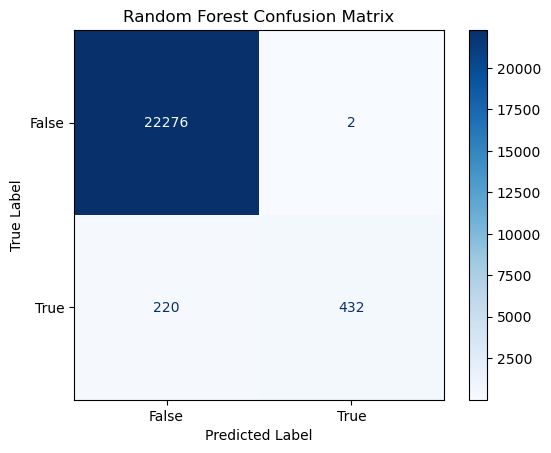

<Figure size 600x400 with 0 Axes>

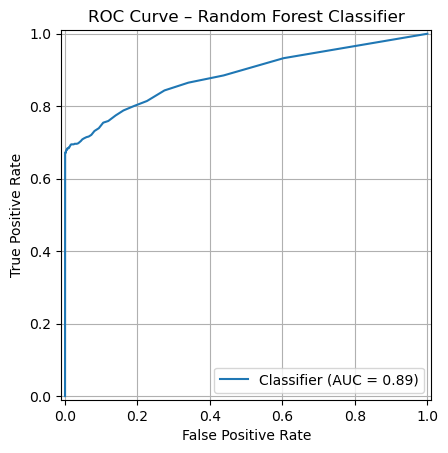

<Figure size 600x400 with 0 Axes>

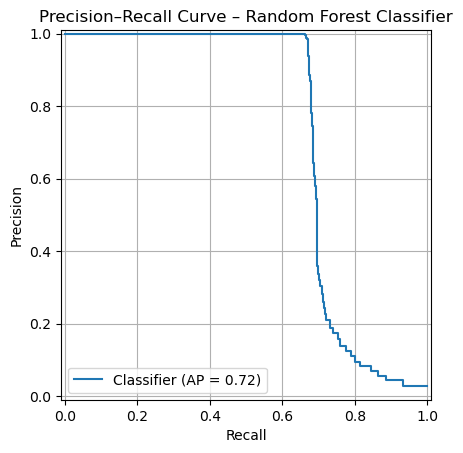

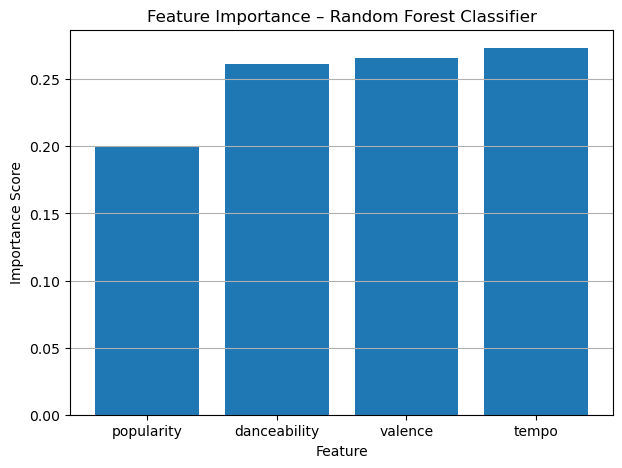

In [25]:
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay

# matrix
plt.figure(figsize=(6,4))
ConfusionMatrixDisplay.from_estimator(rf_model, X_test, y_test, cmap="Blues")
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# ROC Curve
y_proba = rf_model.predict_proba(X_test)[:, 1]

plt.figure(figsize=(6,4))
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title("ROC Curve – Random Forest Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.grid(True)
plt.show()

# Precision Recall Curve
plt.figure(figsize=(6,4))
PrecisionRecallDisplay.from_predictions(y_test, y_proba)
plt.title("Precision–Recall Curve – Random Forest Classifier")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid(True)
plt.show()

# Feature Importance PLot
importances = rf_model.feature_importances_
feature_names = X.columns

plt.figure(figsize=(7,5))
plt.bar(feature_names, importances)
plt.title("Feature Importance – Random Forest Classifier")
plt.xlabel("Feature")
plt.ylabel("Importance Score")
plt.grid(axis="y")
plt.show()

###  b. Interactive Plotly (ROC curve with hover threshold values)

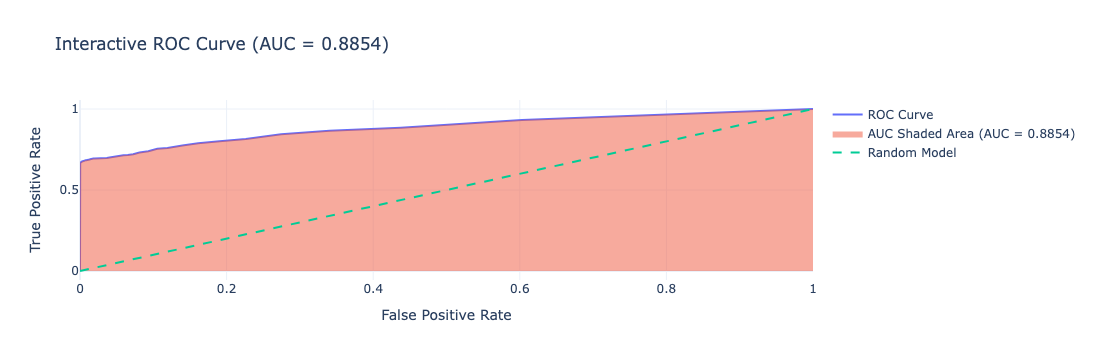

In [24]:
from sklearn.metrics import roc_curve
import plotly.graph_objects as go

# ROC curve
y_proba = rf_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=fpr, 
    y=tpr,
    mode='lines',
    name='ROC Curve',
    hovertext=[f"Threshold: {thr:.4f}" for thr in thresholds],
    hoverinfo='text'
))

# Shaded AUC
fig.add_trace(go.Scatter(
    x=fpr,
    y=tpr,
    fill='tozeroy',
    opacity=0.3,
    line=dict(width=0),
    name=f"AUC Shaded Area (AUC = {auc_score:.4f})"
))

# Baseline
fig.add_trace(go.Scatter(
    x=[0, 1], 
    y=[0, 1],
    mode='lines',
    name='Random Model',
    line=dict(dash='dash')
))

fig.update_layout(
    title=f"Interactive ROC Curve (AUC = {auc_score:.4f})",
    xaxis_title="False Positive Rate",
    yaxis_title="True Positive Rate",
    template="plotly_white"
)

fig.show()

